In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([0.002, 0.005])

train_file = "../experiment_data/n7_tube_train_dataset.npz"
valid_file = "../experiment_data/n7_tube_test_dataset.npz"

# train_file = "../experiment_data/tube_data/7_noded/n7_traj8_tube_dataset_27_pts.npz"
# valid_file = "../experiment_data/tube_data/7_noded/n7_traj8_tube_dataset_27_pts.npz"


In [3]:
from properties import TubeN7Properties

properties = TubeN7Properties(mass=0.005)

In [4]:
params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(42),
    hidden=(10,),
    which_case="MLP",
    corr_factor=1,
    input_mode="raw",
    zero_reference=True,
    activation="tanh",
)

# model_cls = DiagonalPlusEnergyNN
# model_cls = StructuredBrazierCholeskyEnergyNN
model_cls = StructuredBrazierDiagonalEnergyNN
# model_cls = CholeskyPlusEnergyNN

# final_model, train_history, valid_history = train_model(properties=properties, model_cls=model_cls, params=params, train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2)

In [ ]:
final_model, train_history, valid_history = train_model(
    properties=properties,
    model_cls=model_cls,
    params=params,
    train_file=train_file,
    valid_file=valid_file,
    n_epochs=1000,
    lr=5e-3,
    max_dlambda=5e-3,
    iters=10,
    ls_steps=10,
    abs_tol=5e-4,
    rel_tol=1e-4,
    fail_on_nonconvergence=True,
    hessian_reg_strength=1e-6,
    ## early stopping and overfitting control
    early_stopping_warmup_epochs=200,
    early_stopping_patience=200,
    early_stopping_min_delta=1e-5,
    restore_best_model=True,
)

/Users/radha/GitRepos/dismech-jax/.venv/lib/python3.13/site-packages/equinox/_module/_better_abstract.py:233: RuntimeWarning: StructuredBrazierDiagonalEnergyNN received params.mode=None; defaulting to isotropic mode.
  self = super().__call__(*args, **kwargs)


Epoch 000 | Train total: 5.812e-01 | Train disp: 9.593e-03 | Train force: 0.000e+00 | Valid total: 1.139e-02 | Valid disp: 1.139e-02 | Valid force: 0.000e+00
Epoch 100 | Train total: 1.605e-02 | Train disp: 4.327e-03 | Train force: 0.000e+00 | Valid total: 4.855e-03 | Valid disp: 4.855e-03 | Valid force: 0.000e+00
Epoch 200 | Train total: 5.906e-03 | Train disp: 2.552e-03 | Train force: 0.000e+00 | Valid total: 2.654e-03 | Valid disp: 2.654e-03 | Valid force: 0.000e+00
Epoch 300 | Train total: 3.637e-03 | Train disp: 1.819e-03 | Train force: 0.000e+00 | Valid total: 1.744e-03 | Valid disp: 1.744e-03 | Valid force: 0.000e+00
Epoch 400 | Train total: 2.499e-03 | Train disp: 1.423e-03 | Train force: 0.000e+00 | Valid total: 1.267e-03 | Valid disp: 1.267e-03 | Valid force: 0.000e+00
Epoch 500 | Train total: 1.854e-03 | Train disp: 1.195e-03 | Train force: 0.000e+00 | Valid total: 1.011e-03 | Valid disp: 1.011e-03 | Valid force: 0.000e+00
Epoch 600 | Train total: 1.516e-03 | Train disp: 1.0

1000


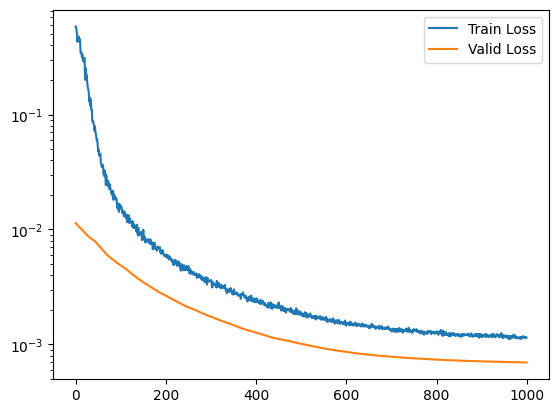

In [6]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [7]:
base, aux = get_slinky(properties)
valid = Dataset.load(valid_file)
train = Dataset.load(train_file)

pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)
pred_train = predict(final_model, base, aux, train.idx_b, train.xb, train.lambdas)

In [8]:
animate(pred[0])

In [9]:
animate(valid.qs[0])

In [10]:
animate(pred[-1])

In [11]:
animate(valid.qs[-1])

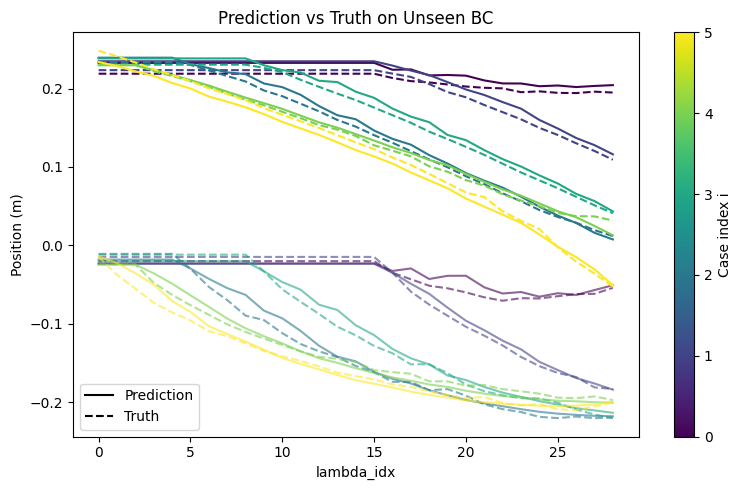

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))
center_node = properties.N // 2

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4*center_node + 0], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4*center_node + 0], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 4*center_node + 2], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 4*center_node + 2], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

In [13]:
print(final_model.get_K0())

[0.00101143 0.00259738]
